In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

## Data Pre-Processing

In [2]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\Data Analytics and Visualization\Capstone Project\Telco Customer Churn.csv")

df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5248-YGIJN,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),90.25,6369.45,No
1,6234-RAAPL,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),99.90,7251.7,No
2,5954-BDFSG,Female,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),107.50,7853.7,No
3,0526-SXDJP,Male,0,Yes,No,72,No,No phone service,DSL,Yes,...,Yes,No,No,No,Two year,No,Bank transfer (automatic),42.10,2962,No
4,9848-JQJTX,Male,0,No,No,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),100.90,7459.05,No
5,6728-DKUCO,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,One year,Yes,Electronic check,104.15,7303.05,No
6,2848-YXSMW,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.40,1363.25,No
7,6734-PSBAW,Male,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),23.55,1723.95,No
8,3146-MSEGF,Female,1,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),88.05,6425.65,No
9,5997-OPVFA,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.05,6254.45,No


In [3]:
df.shape

(7043, 21)

In [4]:
data_struc = pd.DataFrame({
      'Data Type' : df.dtypes,
      'Non-Missing Values' : df.notnull().sum(),
      'Null Values' : df.isna().sum(),
      'Null Values %' : df.isna().mean()*100,
      'Unique Values' : df.nunique()
})

data_struc

,Data Type,Non-Missing Values,Null Values,Null Values %,Unique Values
customerID,object,7043,0,0.0,7043
gender,object,7043,0,0.0,2
SeniorCitizen,int64,7043,0,0.0,2
Partner,object,7043,0,0.0,2
Dependents,object,7043,0,0.0,2
tenure,int64,7043,0,0.0,73
PhoneService,object,7043,0,0.0,2
MultipleLines,object,7043,0,0.0,3
InternetService,object,7043,0,0.0,3
OnlineSecurity,object,7043,0,0.0,3


## Encoding

In [5]:
categ_cols = df.select_dtypes(include='object').columns

categ_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [6]:
df['customerID'].nunique()

7043

**Encode Binary Columns**

In [7]:
yes_no_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

df[yes_no_cols] = df[yes_no_cols].replace({
    'Yes': 1,
    'No': 0
})

df['gender'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})

C:\Users\USER\AppData\Local\Temp\ipykernel_40352\1213325628.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_cols] = df[yes_no_cols].replace({


In [8]:
(df['Churn'] == 0).sum()

np.int64(5174)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
data_structure = pd.DataFrame({
      'Data Type' : df.dtypes,
      'Non-Missing Values' : df.notnull().sum(),
      'Null Values' : df.isna().sum(),
      'Null Values %' : df.isna().mean()*100,
      'Unique Values' : df.nunique()
})

data_structure

,Data Type,Non-Missing Values,Null Values,Null Values %,Unique Values
customerID,object,7043,0,0.0,7043
gender,int64,7043,0,0.0,2
SeniorCitizen,int64,7043,0,0.0,2
Partner,int64,7043,0,0.0,2
Dependents,int64,7043,0,0.0,2
tenure,int64,7043,0,0.0,73
PhoneService,int64,7043,0,0.0,2
MultipleLines,object,7043,0,0.0,3
InternetService,object,7043,0,0.0,3
OnlineSecurity,object,7043,0,0.0,3


In [11]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

df['TotalCharges'].dtype

dtype('float64')

In [12]:
df['expected_total'] = df['tenure'] * df['MonthlyCharges']
df['charge_diff'] = df['TotalCharges'] - df['expected_total']

In [13]:
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'expected_total', 'charge_diff']].head(20)

,tenure,MonthlyCharges,TotalCharges,expected_total,charge_diff
0,72,90.25,6369.45,6498.0,-128.55
1,72,99.90,7251.70,7192.8,58.90
2,72,107.50,7853.70,7740.0,113.70
3,72,42.10,2962.00,3031.2,-69.20
4,72,100.90,7459.05,7264.8,194.25
5,72,104.15,7303.05,7498.8,-195.75
6,72,19.40,1363.25,1396.8,-33.55
7,72,23.55,1723.95,1695.6,28.35
8,72,88.05,6425.65,6339.6,86.05
9,72,89.05,6254.45,6411.6,-157.15


In [14]:
df['charge_diff'].max()

np.float64(373.2500000000009)

In [15]:
df['charge_diff'].min()

np.float64(-370.84999999999945)

In [16]:
df['charge_diff_group'] = np.where(
      df['charge_diff'] < 0,
      'Negative',
      np.where(
            df['charge_diff'] > 0,
            'Positive',
            'Zero'
      )
      )

In [17]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,expected_total,charge_diff
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,0.265370,2279.581350,0.152953
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561,2264.729447,67.202778
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,-370.850000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,394.000000,-28.600000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000,1393.600000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,3786.100000,28.500000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,8550.000000,373.250000


**Reusable visual theme**

In [18]:
def apply_house_style(ax, title=None, xlabel=None, ylabel=None):
    # Remove unnecessary borders
    ax.spines[["top", "right"]].set_visible(False)

    # Subtle horizontal grid
    ax.grid(axis="y", alpha=0.25)

    # Clean tick marks
    ax.tick_params(axis="both", length=0)

    # Labels
    if xlabel:
        ax.set_xlabel(xlabel)

    if ylabel:
        ax.set_ylabel(ylabel)

    # Left-aligned bold title
    if title:
        ax.set_title(
            title,
            loc="left",
            fontweight="bold",
            pad=12
        )

    return ax

## Univariate Analysis

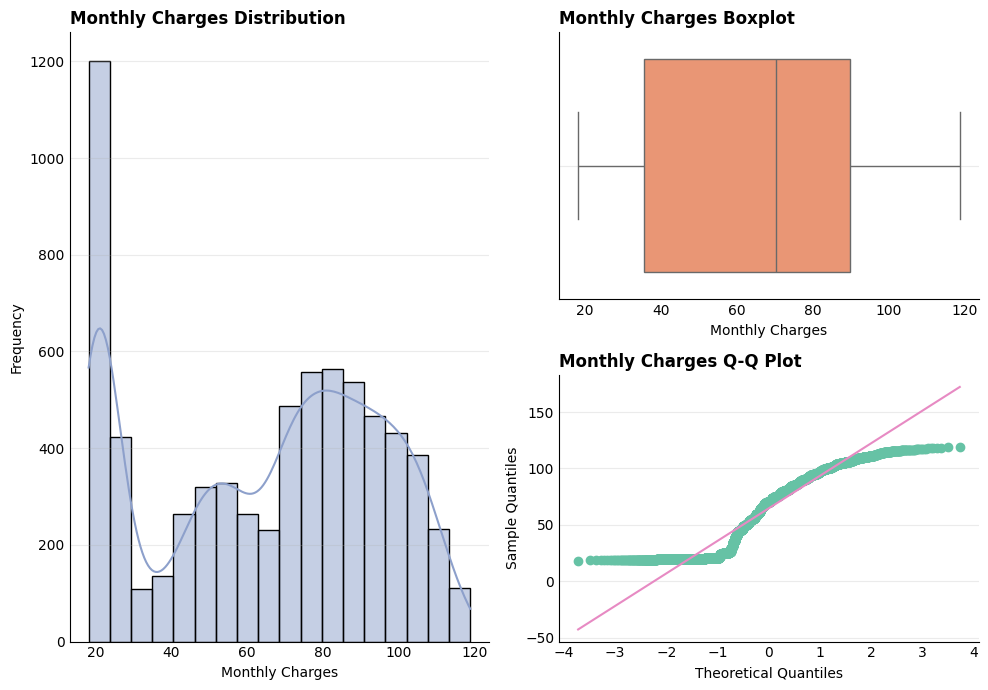

In [19]:
# Monthly Charges Distribution, Boxplot, and Q-Q Plot
fig, ax = plt.subplot_mosaic(
    "AB\nAC",
    figsize=(10, 7)
)

palette = sns.color_palette("Set2", 4)

# Histogram
sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True,
    color=palette[2],
    ax=ax["A"]
)

apply_house_style(
    ax=ax["A"],
    title="Monthly Charges Distribution",
    xlabel="Monthly Charges",
    ylabel="Frequency"
)

# Boxplot
sns.boxplot(
    data=df,
    x="MonthlyCharges",
    color=palette[1],
    ax=ax["B"]
)

apply_house_style(
    ax=ax["B"],
    title="Monthly Charges Boxplot",
    xlabel="Monthly Charges",
    ylabel=None
)

# Q-Q Plot
stats.probplot(
    df["MonthlyCharges"],
    dist="norm",
    plot=ax["C"]
)

# Apply palette to Q-Q plot
ax["C"].get_lines()[0].set_color(palette[0])
ax["C"].get_lines()[1].set_color(palette[3])

apply_house_style(
    ax=ax["C"],
    title="Monthly Charges Q-Q Plot",
    xlabel="Theoretical Quantiles",
    ylabel="Sample Quantiles"
)

# Remove duplicate titles
ax["A"].set_title("")
ax["B"].set_title("")
ax["C"].set_title("")

plt.tight_layout()
plt.show()

> **Monthly Charges are not normally distributed.** The histogram shows a distinctly **bimodal distribution**, with concentrations at lower charges around **$20–$30** and higher charges around **$70–$100**. The boxplot shows a **median of approximately $70** and **no prominent outliers**. The Q-Q plot deviates substantially from the reference line, particularly at the tails, confirming that the variable **does not follow a normal distribution**.

don't automatically **log-transform** MonthlyCharges just because it's non-normal. The bimodality appears to reflect different customer/service groups, so a transformation wouldn't necessarily solve the underlying structure.

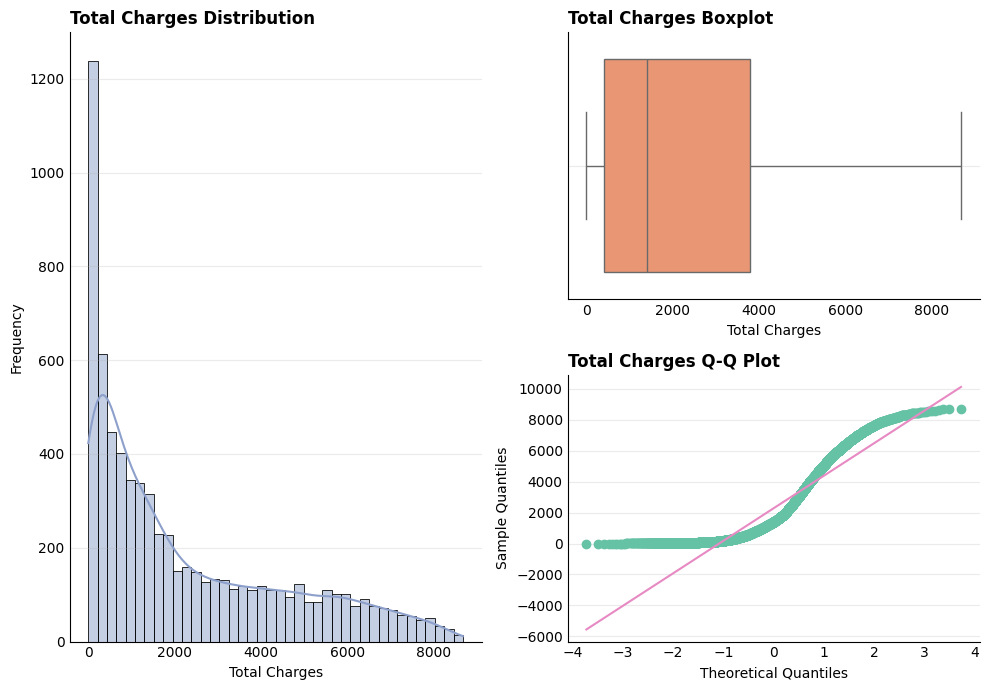

In [20]:
# Total Charges Distribution, Boxplot, and Q-Q Plot
fig, ax = plt.subplot_mosaic(
    "AB\nAC",
    figsize=(10, 7)
)

palette = sns.color_palette("Set2", 4)

# Histogram
sns.histplot(
    data=df,
    x="TotalCharges",
    kde=True,
    bins=40,
    color=palette[2],
    ax=ax["A"]
)

apply_house_style(
    ax=ax["A"],
    title="Total Charges Distribution",
    xlabel="Total Charges",
    ylabel="Frequency"
)

# Boxplot
sns.boxplot(
    data=df,
    x="TotalCharges",
    color=palette[1],
    ax=ax["B"]
)

apply_house_style(
    ax=ax["B"],
    title="Total Charges Boxplot",
    xlabel="Total Charges",
    ylabel=None
)

# Q-Q Plot
stats.probplot(
    df["TotalCharges"],
    dist="norm",
    plot=ax["C"]
)

ax["C"].get_lines()[0].set_color(palette[0])
ax["C"].get_lines()[1].set_color(palette[3])

apply_house_style(
    ax=ax["C"],
    title="Total Charges Q-Q Plot",
    xlabel="Theoretical Quantiles",
    ylabel="Sample Quantiles"
)

# Remove duplicate titles
ax["A"].set_title("")
ax["B"].set_title("")
ax["C"].set_title("")

plt.tight_layout()
plt.show()

Total Charges is **highly positively skewed**, with **most customers** having relatively **low accumulated charges** and a smaller number having very high charges. The substantial deviation from the Q-Q reference line indicates that the **variable does not satisfy the assumption of normality.**

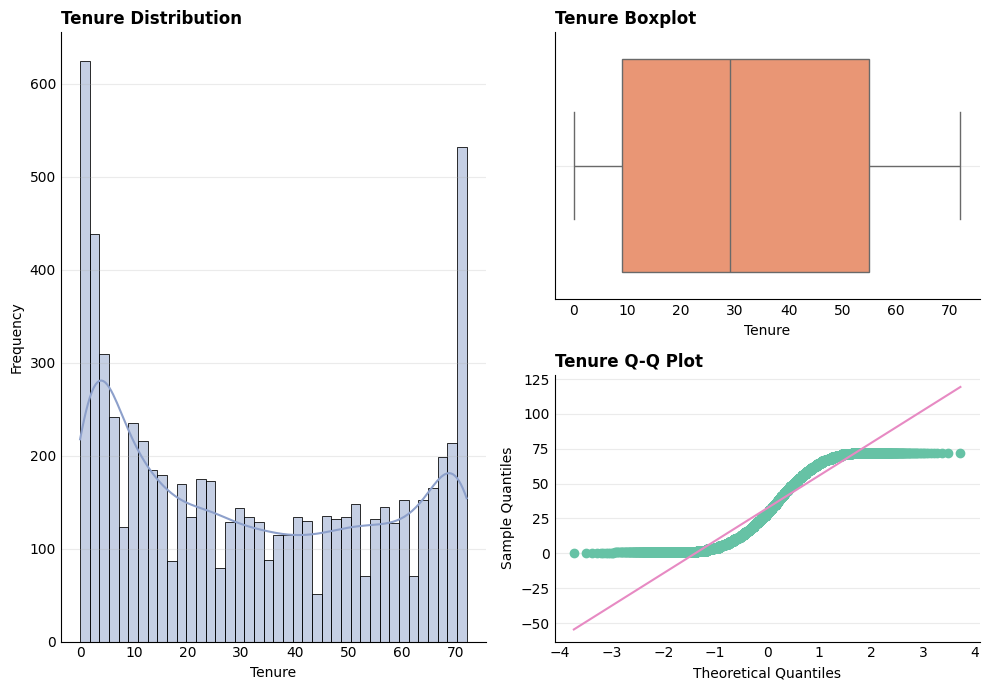

In [21]:
# Tenure
fig, ax = plt.subplot_mosaic(
    "AB\nAC",
    figsize=(10, 7)
)

palette = sns.color_palette("Set2", 4)

# Histogram
sns.histplot(
    data=df,
    x="tenure",
    kde=True,
    bins=40,
    color=palette[2],
    ax=ax["A"]
)

apply_house_style(
    ax=ax["A"],
    title="Tenure Distribution",
    xlabel="Tenure",
    ylabel="Frequency"
)

# Boxplot
sns.boxplot(
    data=df,
    x="tenure",
    color=palette[1],
    ax=ax["B"]
)

apply_house_style(
    ax=ax["B"],
    title="Tenure Boxplot",
    xlabel="Tenure",
    ylabel=None
)

# Q-Q Plot
stats.probplot(
    df["tenure"],
    dist="norm",
    plot=ax["C"]
)

ax["C"].get_lines()[0].set_color(palette[0])
ax["C"].get_lines()[1].set_color(palette[3])

apply_house_style(
    ax=ax["C"],
    title="Tenure Q-Q Plot",
    xlabel="Theoretical Quantiles",
    ylabel="Sample Quantiles"
)

# Remove duplicate titles
ax["A"].set_title("")
ax["B"].set_title("")
ax["C"].set_title("")

plt.tight_layout()
plt.show()

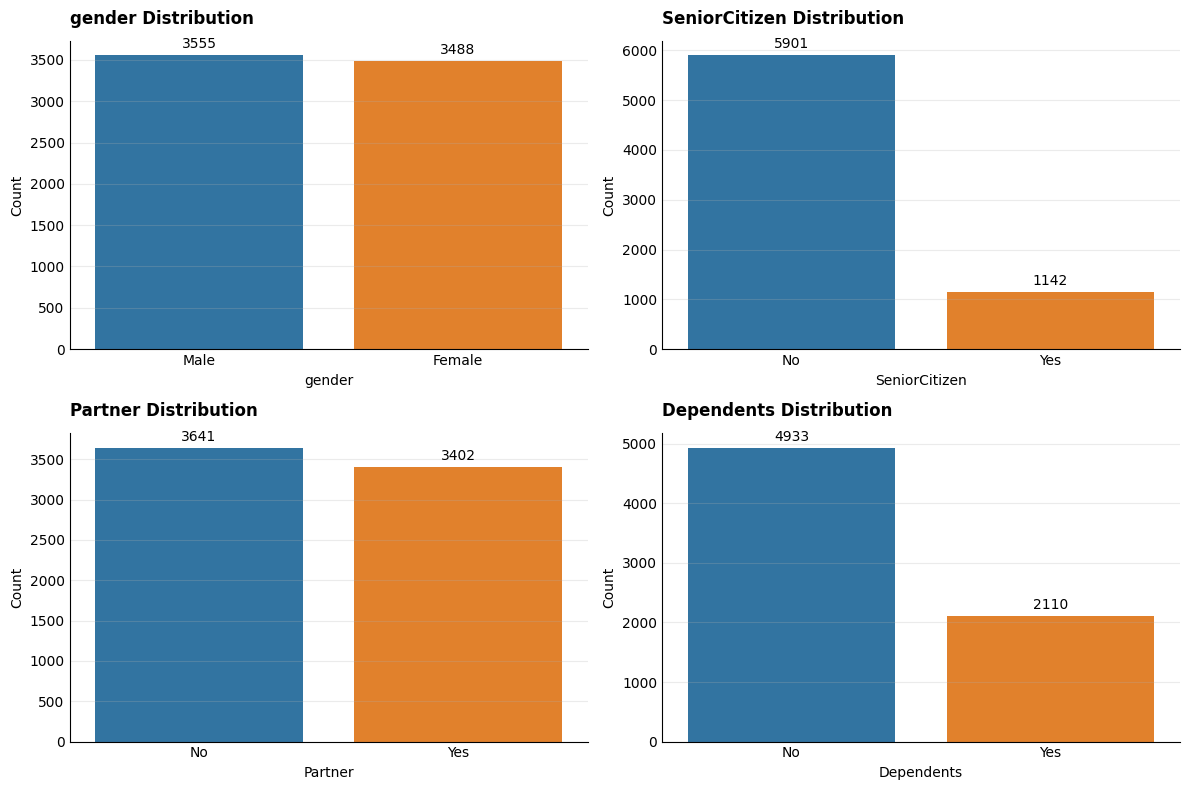

In [22]:
fig, ax = plt.subplot_mosaic(
    [
        ['gender', 'SeniorCitizen'],
        ['Partner', 'Dependents']
    ],
    figsize=(12, 8)
)

labels = {
    'gender': ['Male', 'Female'],
    'SeniorCitizen': ['No', 'Yes'],
    'Partner': ['No', 'Yes'],
    'Dependents': ['No', 'Yes']
}

for col in labels:
    sns.countplot(
        data=df,
        x=col,
        palette='tab10',
        hue = col,
        legend=False,
        ax=ax[col]
    )

    ax[col].set_xticks(range(2))
    ax[col].set_xticklabels(labels[col])

    apply_house_style(
        ax[col],
        title=f'{col} Distribution',
        xlabel='',
        ylabel='Count'
    )

    # Add count labels
    for container in ax[col].containers:
        ax[col].bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

In [23]:
categ_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [24]:
for col in categ_cols:
    print(f'\n{col}')
    print(
        pd.DataFrame({
            'Count': df[col].value_counts(),
            'Percentage': df[col].value_counts(normalize=True).mul(100).round(2)
        })
    )


MultipleLines
                  Count  Percentage
MultipleLines                      
No                 3390       48.13
Yes                2971       42.18
No phone service    682        9.68

InternetService
                 Count  Percentage
InternetService                   
Fiber optic       3096       43.96
DSL               2421       34.37
No                1526       21.67

OnlineSecurity
                     Count  Percentage
OnlineSecurity                        
No                    3498       49.67
Yes                   2019       28.67
No internet service   1526       21.67

OnlineBackup
                     Count  Percentage
OnlineBackup                          
No                    3088       43.84
Yes                   2429       34.49
No internet service   1526       21.67

DeviceProtection
                     Count  Percentage
DeviceProtection                      
No                    3095       43.94
Yes                   2422       34.39
No internet service

**Phone Service & Add-on Distribution**

In [25]:
phone_col = {
      'PhoneService',
      'MultipleLines'
}

for col in phone_col:
      print(f'\n{col}')
      print(
            pd.DataFrame({
                  'Count': df[col].value_counts(),
                  'Percentage': df[col].value_counts(normalize=True).mul(100).round(2)
            })
      )


PhoneService
              Count  Percentage
PhoneService                   
1              6361       90.32
0               682        9.68

MultipleLines
                  Count  Percentage
MultipleLines                      
No                 3390       48.13
Yes                2971       42.18
No phone service    682        9.68


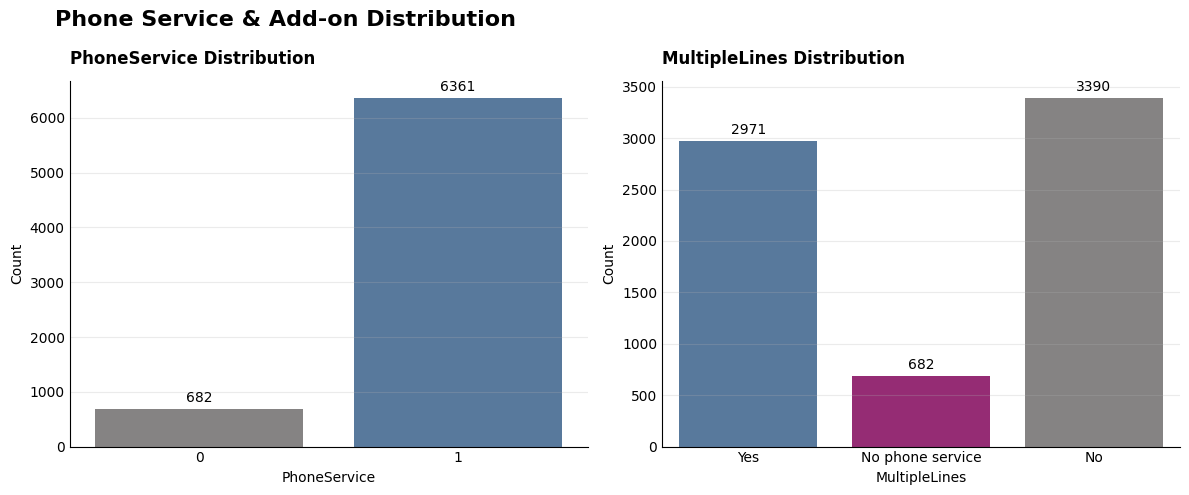

In [26]:
phone = {
      'base': 'PhoneService',
      'addon': 'MultipleLines'
}

phone_palette = {
    'PhoneService': {
        0: '#868282',
        1: '#4C78A8'
    },
    'MultipleLines': {
        'No phone service': "#A61B7A",
        'No': "#868282",
        'Yes': '#4C78A8'
    }
}

fig, ax = plt.subplot_mosaic(
    [['base', 'addon']],
    figsize=(12, 5)
)

for key, col in phone.items():
      sns.countplot(
            data = df,
            x = col,
            hue = col,
            palette = phone_palette[col],
            legend = False,
            ax=ax[key]
      )
      # Add count labels
      for container in ax[key].containers:
            ax[key].bar_label(
                  container,
                  fmt='%d',
                  padding=3,
                  fontsize=10
                  )

apply_house_style(
      ax = ax['base'],
      title = f'{phone["base"]} Distribution',
      xlabel = '',
      ylabel = 'Count'
)
apply_house_style(
      ax = ax['addon'],
      title = f'{phone["addon"]} Distribution',
      xlabel = '',
      ylabel = 'Count'
)

fig.suptitle(
    'Phone Service & Add-on Distribution',
    fontsize=16,
    fontweight='bold',
    x=0.05,
    ha='left'
)

plt.tight_layout()
plt.show()

**Internet Service & Add-on Distribution**

In [27]:
internet_cols = {
      'base': 'InternetService',
      'security': 'OnlineSecurity',
      'backup': 'OnlineBackup',
      'protection': 'DeviceProtection',
      'support': 'TechSupport',
      'tv': 'StreamingTV',
      'movie' : "StreamingMovies"
}

for col in internet_cols:
      print(f'\n{internet_cols[col]}')
      print(
            pd.DataFrame({
                  'Count': df[internet_cols[col]].value_counts(),
                  'Percentage': df[internet_cols[col]].value_counts(normalize=True).mul(100).round(2)
            })
      )


InternetService
                 Count  Percentage
InternetService                   
Fiber optic       3096       43.96
DSL               2421       34.37
No                1526       21.67

OnlineSecurity
                     Count  Percentage
OnlineSecurity                        
No                    3498       49.67
Yes                   2019       28.67
No internet service   1526       21.67

OnlineBackup
                     Count  Percentage
OnlineBackup                          
No                    3088       43.84
Yes                   2429       34.49
No internet service   1526       21.67

DeviceProtection
                     Count  Percentage
DeviceProtection                      
No                    3095       43.94
Yes                   2422       34.39
No internet service   1526       21.67

TechSupport
                     Count  Percentage
TechSupport                           
No                    3473       49.31
Yes                   2044       29.02
No int

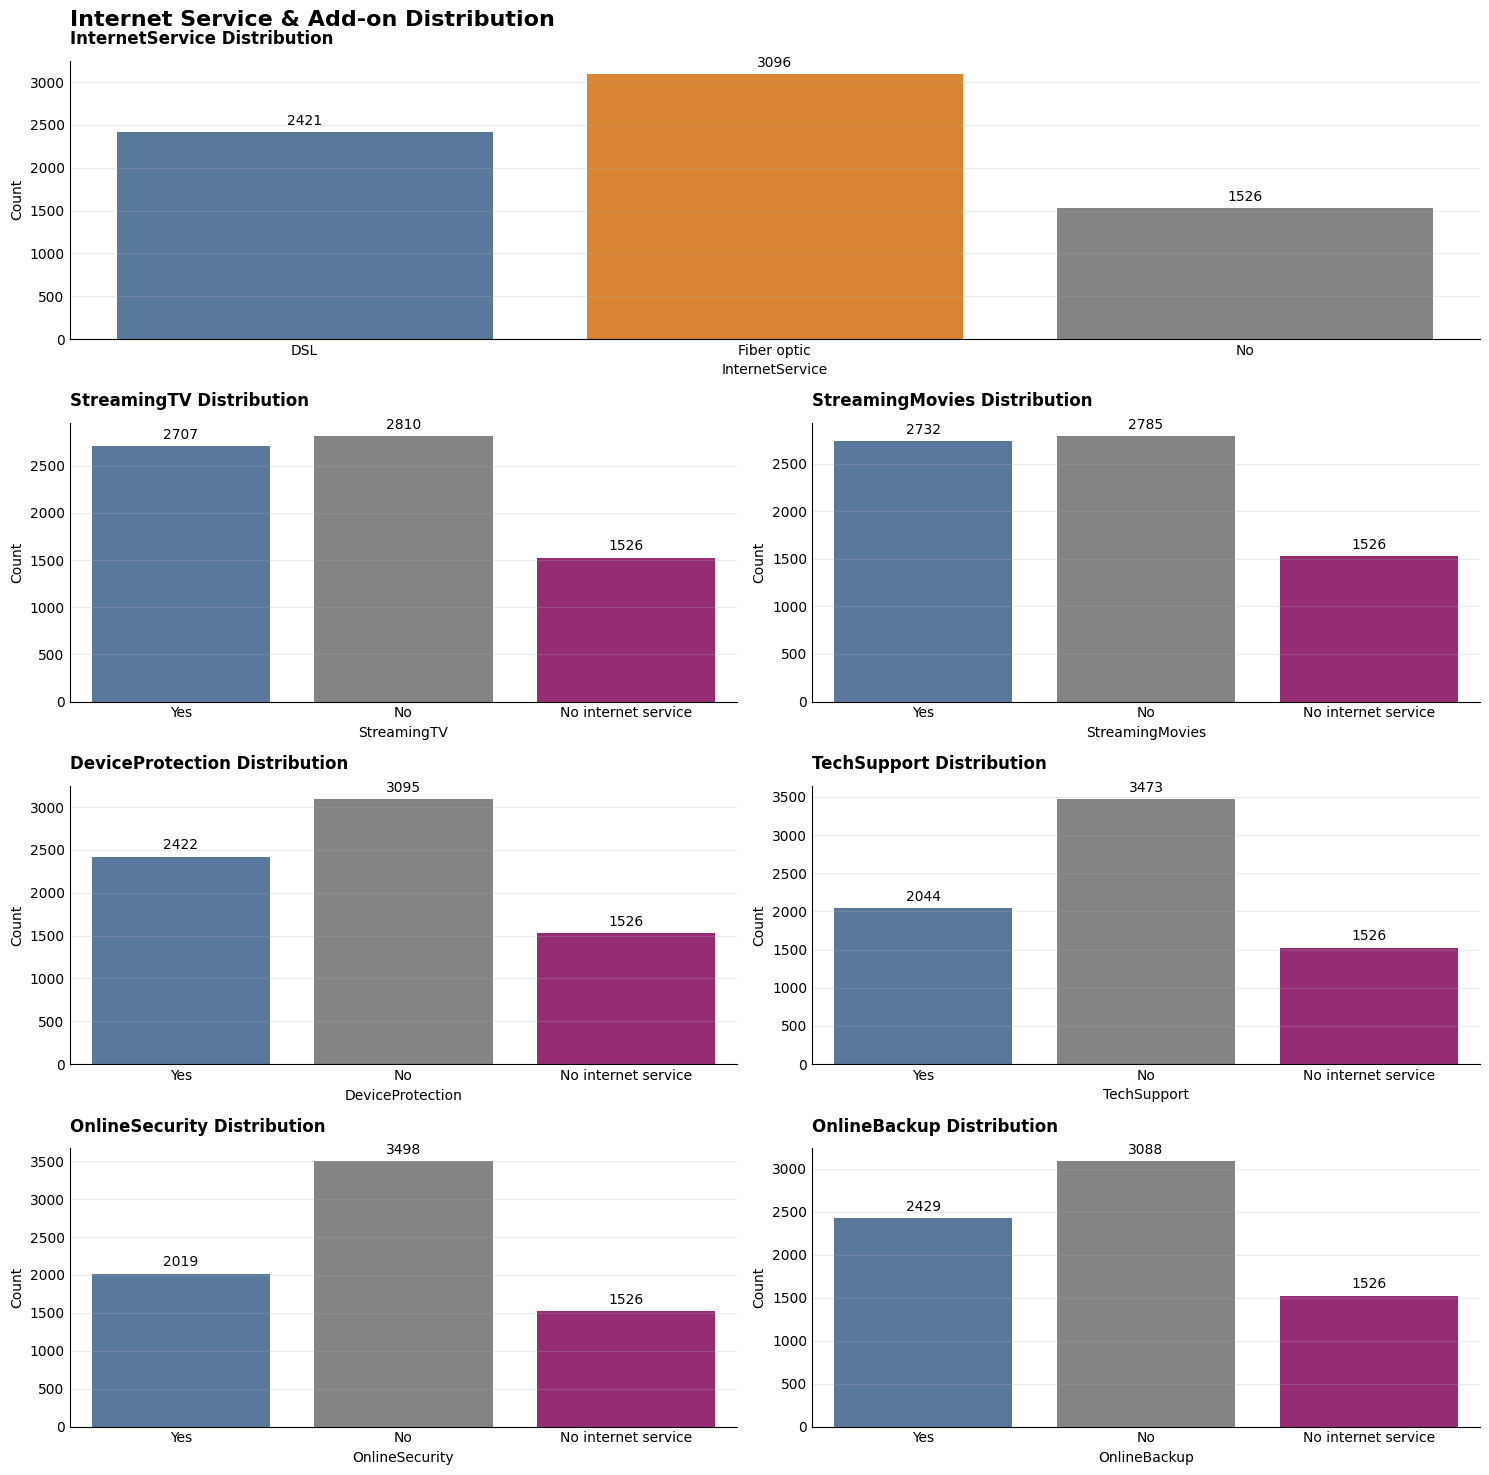

In [28]:
internet_palette = {
    'InternetService': {
        'DSL': '#4C78A8',
        'Fiber optic': '#F58518',
        'No': '#868282'
    },
    'OnlineSecurity': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    },
    'OnlineBackup': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    },
    'DeviceProtection': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    },
    'TechSupport': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    },
    'StreamingTV': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    },
    'StreamingMovies': {
        'No internet service': '#A61B7A',
        'No': '#868282',
        'Yes': '#4C78A8'
    }
}

fig, ax = plt.subplot_mosaic(
    [
        ['base', 'base'],
        ['tv', 'movie'],
        ['protection', 'support'],
        ['security', 'backup']
    ],
    figsize=(15, 15)
)

for key, col in internet_cols.items():

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette=internet_palette[col],
        legend=False,
        ax=ax[key]
    )

    # Add count labels
    for container in ax[key].containers:
        ax[key].bar_label(
            container,
            fmt='%d',
            padding=3,
            fontsize=10
            )
        
    apply_house_style(
        ax=ax[key],
        title=f'{col} Distribution',
        xlabel='',
        ylabel='Count'
    )

fig.suptitle(
    'Internet Service & Add-on Distribution',
    fontsize=16,
    fontweight='bold',
    x=0.05,
    ha='left'
)

plt.tight_layout()
plt.show()

In [29]:
payment_counts = df['PaymentMethod'].value_counts()
payment_counts

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

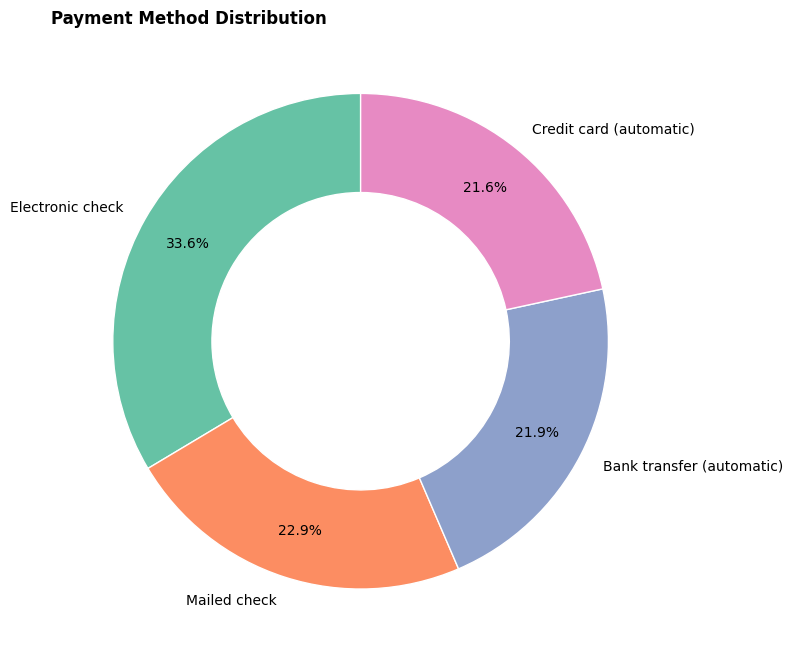

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2", 4),
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.8
)

ax.set_title(
    'Payment Method Distribution',
    fontweight='bold',
    loc='left'
)

plt.tight_layout()
plt.show()

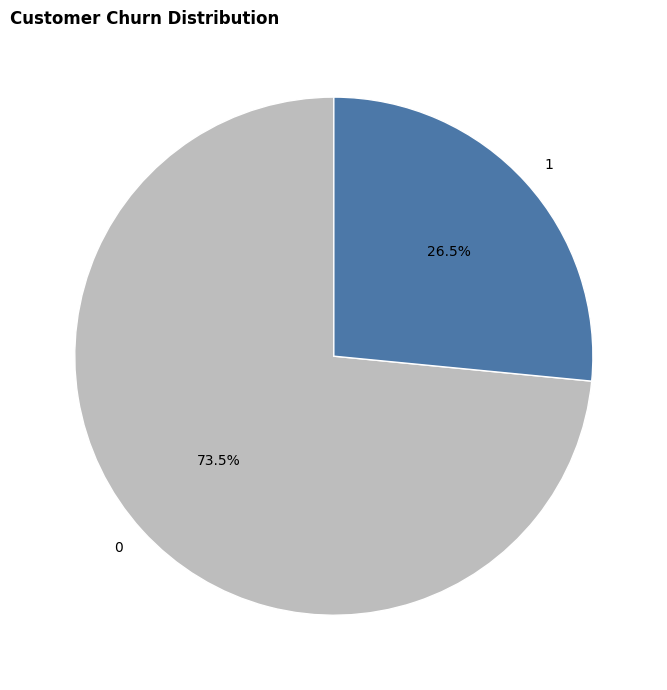

In [31]:
churn_counts = df['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#BDBDBD', '#4C78A8'],
    wedgeprops=dict(edgecolor='white')
)

ax.set_title(
    'Customer Churn Distribution',
    fontweight='bold',
    loc='left'
)

plt.tight_layout()
plt.show()

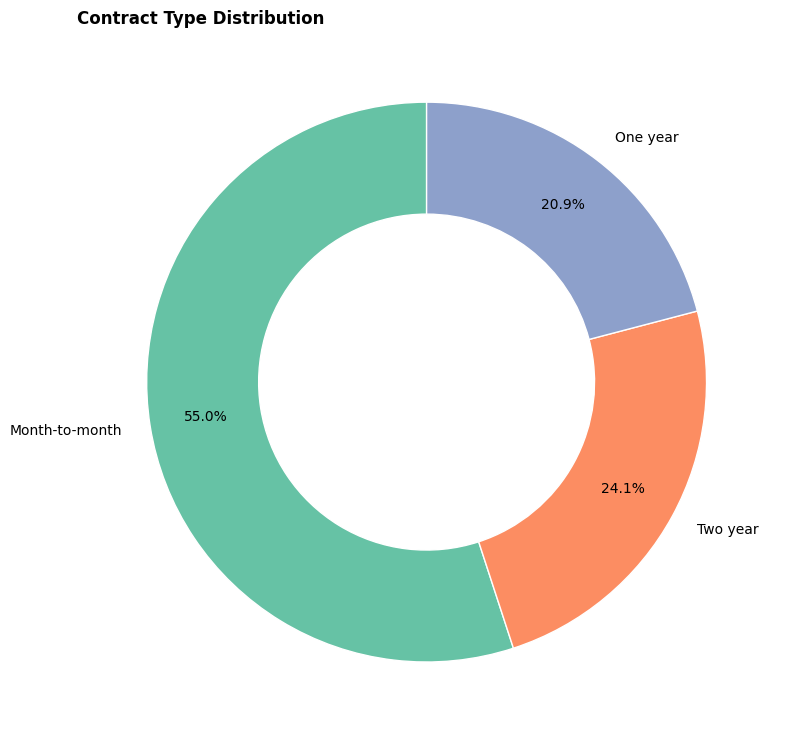

In [32]:
contract_counts = df['Contract'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2", 3),
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.8
)

ax.set_title(
    'Contract Type Distribution',
    fontweight='bold',
    loc='left'
)

plt.tight_layout()
plt.show()

## Multivariate and Bivariate Analysis

**Churn Rate Function**

In [33]:
def churn_rate_by(df, column):
      result = (
            df.groupby(column, observed=True)['Churn']
            .agg(churned = 'sum', total_customers = 'count')
            .assign(churn_rate = lambda x : x['churned'] / x['total_customers'] * 100)
            .reset_index()
            .sort_values(by='churn_rate', ascending=False)
      )

      return result

**Churn Analysis**

In [34]:
result_contract = churn_rate_by(df, 'Contract')
result_gender = churn_rate_by(df, 'gender')
result_senior = churn_rate_by(df, 'SeniorCitizen')
result_partner = churn_rate_by(df, 'Partner')
result_dependents = churn_rate_by(df, 'Dependents')
result_payment = churn_rate_by(df, 'PaymentMethod')

In [35]:
result_contract

,Contract,churned,total_customers,churn_rate
0,Month-to-month,1655,3875,42.709677
1,One year,166,1473,11.269518
2,Two year,48,1695,2.831858


In [36]:
result_gender

,gender,churned,total_customers,churn_rate
1,1,939,3488,26.920872
0,0,930,3555,26.160338


In [37]:
result_senior

,SeniorCitizen,churned,total_customers,churn_rate
1,1,476,1142,41.681261
0,0,1393,5901,23.606168


In [38]:
result_partner

,Partner,churned,total_customers,churn_rate
0,0,1200,3641,32.957979
1,1,669,3402,19.664903


In [39]:
result_dependents

,Dependents,churned,total_customers,churn_rate
0,0,1543,4933,31.279140
1,1,326,2110,15.450237


In [40]:
result_payment

,PaymentMethod,churned,total_customers,churn_rate
2,Electronic check,1071,2365,45.285412
3,Mailed check,308,1612,19.106700
0,Bank transfer (automatic),258,1544,16.709845
1,Credit card (automatic),232,1522,15.243101


In [41]:
##Tenure groups
df['tenure_group'] = pd.cut(
      df['tenure'],
      bins=[0, 12, 24, 48, 60, 72],
      labels = [
            '0-12 (1 year)',
            '12-24 (2 years)',
            '24-48 (4 years)',
            '48-60 (5 years)',
            '60-72 (6 years)'
      ]
)

result_tenure = churn_rate_by(df, 'tenure_group')
result_tenure

,tenure_group,churned,total_customers,churn_rate
0,0-12 (1 year),1037,2175,47.678161
1,12-24 (2 years),294,1024,28.710938
2,24-48 (4 years),325,1594,20.388959
3,48-60 (5 years),120,832,14.423077
4,60-72 (6 years),93,1407,6.609808


In [42]:
# 2. Map encoded values to readable labels
# Gender
result_gender['gender'] = result_gender['gender'].map({
    0: 'Male',
    1: 'Female'
})

# Senior Citizen
result_senior['SeniorCitizen'] = result_senior['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})

# Partner
result_partner['Partner'] = result_partner['Partner'].map({
    0: 'No',
    1: 'Yes'
})

# Dependents
result_dependents['Dependents'] = result_dependents['Dependents'].map({
    0: 'No',
    1: 'Yes'
})

In [43]:
contract_palette = sns.color_palette("viridis", 3)

profile_palette = sns.color_palette("cividis", 2)

gender_palette = sns.color_palette("Set2", 2)

payment_palette = sns.color_palette("magma", len(result_payment))

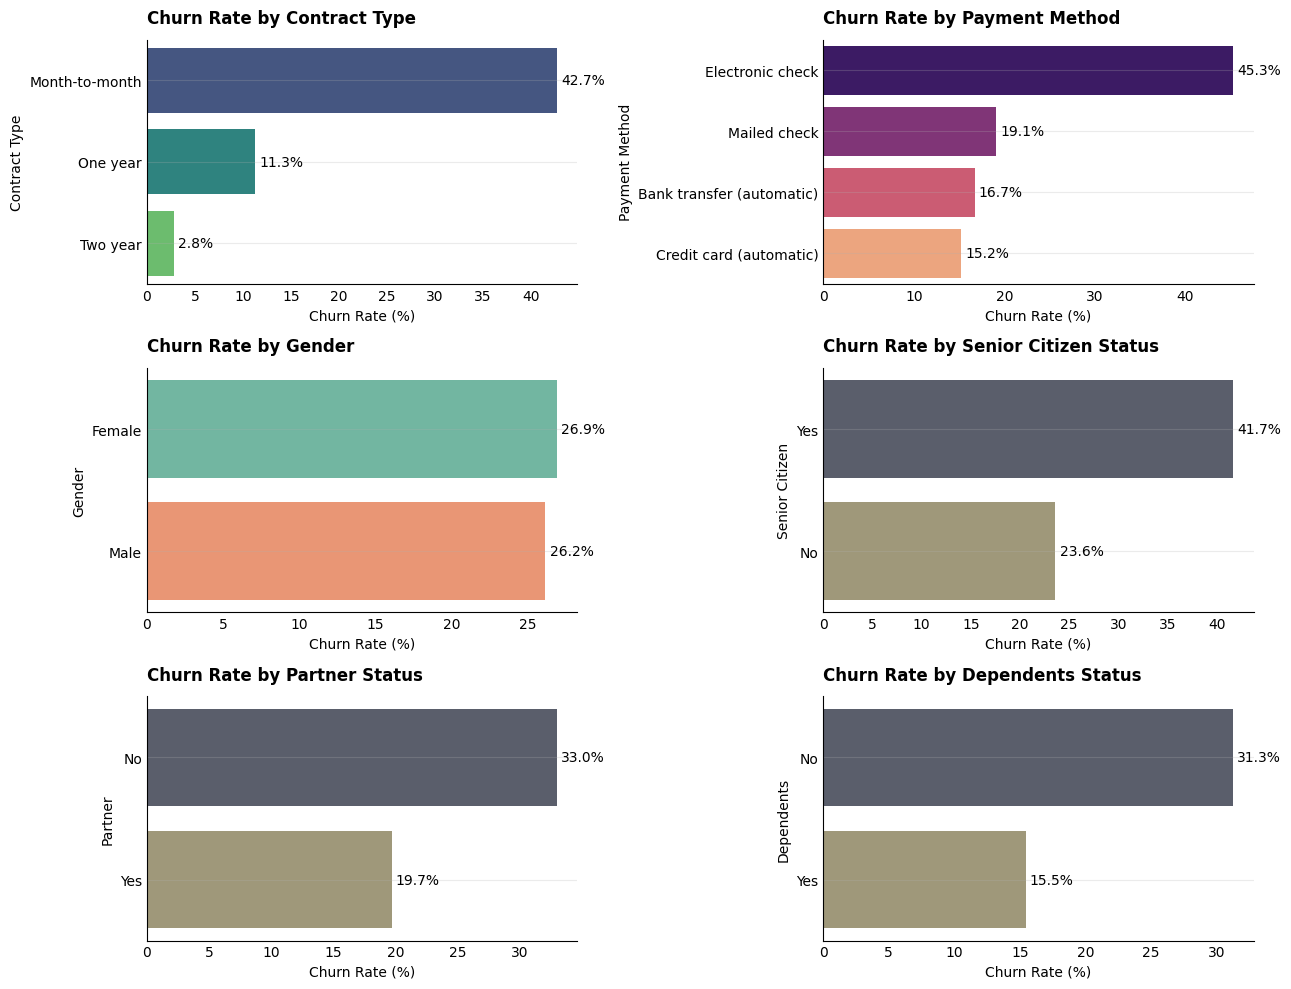

In [44]:
fig, ax = plt.subplot_mosaic(
    [
        ['contract', 'payment'],
        ['gender', 'senior'],
        ['partner', 'dependents']
    ],
    figsize=(13, 10)
)

# ============================================================
# Contract
# ============================================================

sns.barplot(
    data=result_contract,
    x='churn_rate',
    y='Contract',
    hue='Contract',
    palette=contract_palette,
    legend=False,
    ax=ax['contract']
)

apply_house_style(
    ax['contract'],
    title='Churn Rate by Contract Type',
    xlabel='Churn Rate (%)',
    ylabel='Contract Type'
)


# ============================================================
# Payment Method
# ============================================================

sns.barplot(
    data=result_payment,
    x='churn_rate',
    y='PaymentMethod',
    hue='PaymentMethod',
    palette=payment_palette,
    legend=False,
    ax=ax['payment']
)

apply_house_style(
    ax['payment'],
    title='Churn Rate by Payment Method',
    xlabel='Churn Rate (%)',
    ylabel='Payment Method'
)


# ============================================================
# Gender
# ============================================================

sns.barplot(
    data=result_gender,
    x='churn_rate',
    y='gender',
    hue='gender',
    palette=gender_palette,
    legend=False,
    ax=ax['gender']
)

apply_house_style(
    ax['gender'],
    title='Churn Rate by Gender',
    xlabel='Churn Rate (%)',
    ylabel='Gender'
)


# ============================================================
# Senior Citizen
# ============================================================

sns.barplot(
    data=result_senior,
    x='churn_rate',
    y='SeniorCitizen',
    hue='SeniorCitizen',
    palette=profile_palette,
    legend=False,
    ax=ax['senior']
)

apply_house_style(
    ax['senior'],
    title='Churn Rate by Senior Citizen Status',
    xlabel='Churn Rate (%)',
    ylabel='Senior Citizen'
)


# ============================================================
# Partner
# ============================================================

sns.barplot(
    data=result_partner,
    x='churn_rate',
    y='Partner',
    hue='Partner',
    palette=profile_palette,
    legend=False,
    ax=ax['partner']
)

apply_house_style(
    ax['partner'],
    title='Churn Rate by Partner Status',
    xlabel='Churn Rate (%)',
    ylabel='Partner'
)


# ============================================================
# Dependents
# ============================================================

sns.barplot(
    data=result_dependents,
    x='churn_rate',
    y='Dependents',
    hue='Dependents',
    palette=profile_palette,
    legend=False,
    ax=ax['dependents']
)

apply_house_style(
    ax['dependents'],
    title='Churn Rate by Dependents Status',
    xlabel='Churn Rate (%)',
    ylabel='Dependents'
)


# ============================================================
# Add percentage labels
# ============================================================

for axis in ax.values():
    for container in axis.containers:
        axis.bar_label(
            container,
            fmt='%.1f%%',
            padding=3
        )

plt.tight_layout()
plt.show()

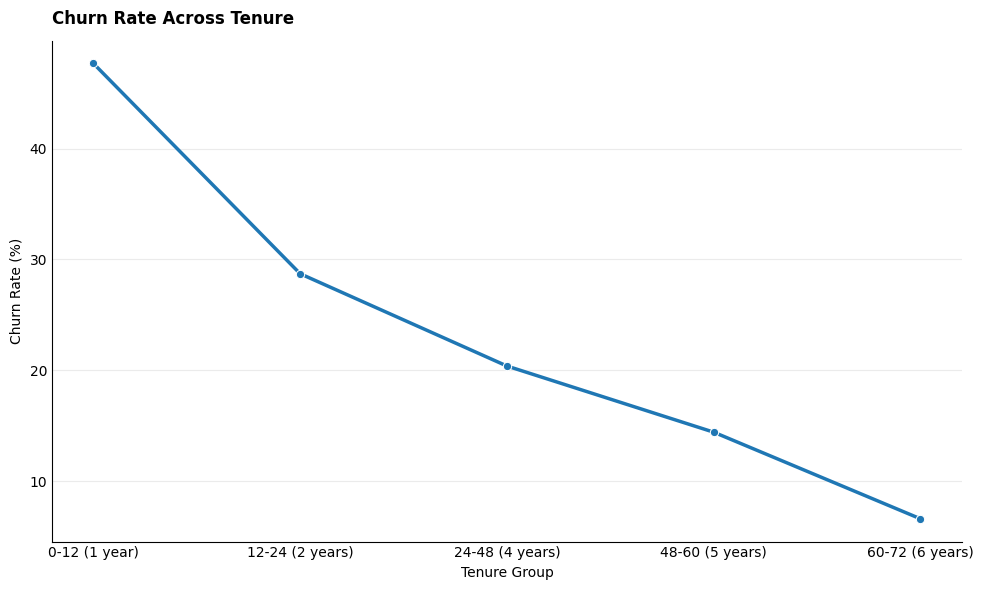

In [45]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=result_tenure.sort_values('tenure_group'),
    x='tenure_group',
    y='churn_rate',
    marker='o',
    linewidth=2.5
)

apply_house_style(
    plt.gca(),
    title='Churn Rate Across Tenure',
    xlabel='Tenure Group',
    ylabel='Churn Rate (%)'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Stayed Function**

In [46]:
def stayed_customers(result, category):
    result = result.copy()

    result['stayed'] = result['total_customers'] - result['churned']

    result['churned_pct'] = (
        result['churned'] / result['total_customers'] * 100
    )

    result['stayed_pct'] = (
        result['stayed'] / result['total_customers'] * 100
    )

    return result

In [47]:
contract = stayed_customers(result_contract, 'Contract')
gender = stayed_customers(result_gender, 'gender')
senior = stayed_customers(result_senior, 'SeniorCitizen')
partner = stayed_customers(result_partner, 'Partner')
dependents = stayed_customers(result_dependents, 'Dependents')
payment = stayed_customers(result_payment, 'PaymentMethod')

In [48]:
stack_palette = sns.color_palette("Set2", 2)

churned_color = stack_palette[0]
stayed_color = stack_palette[1]

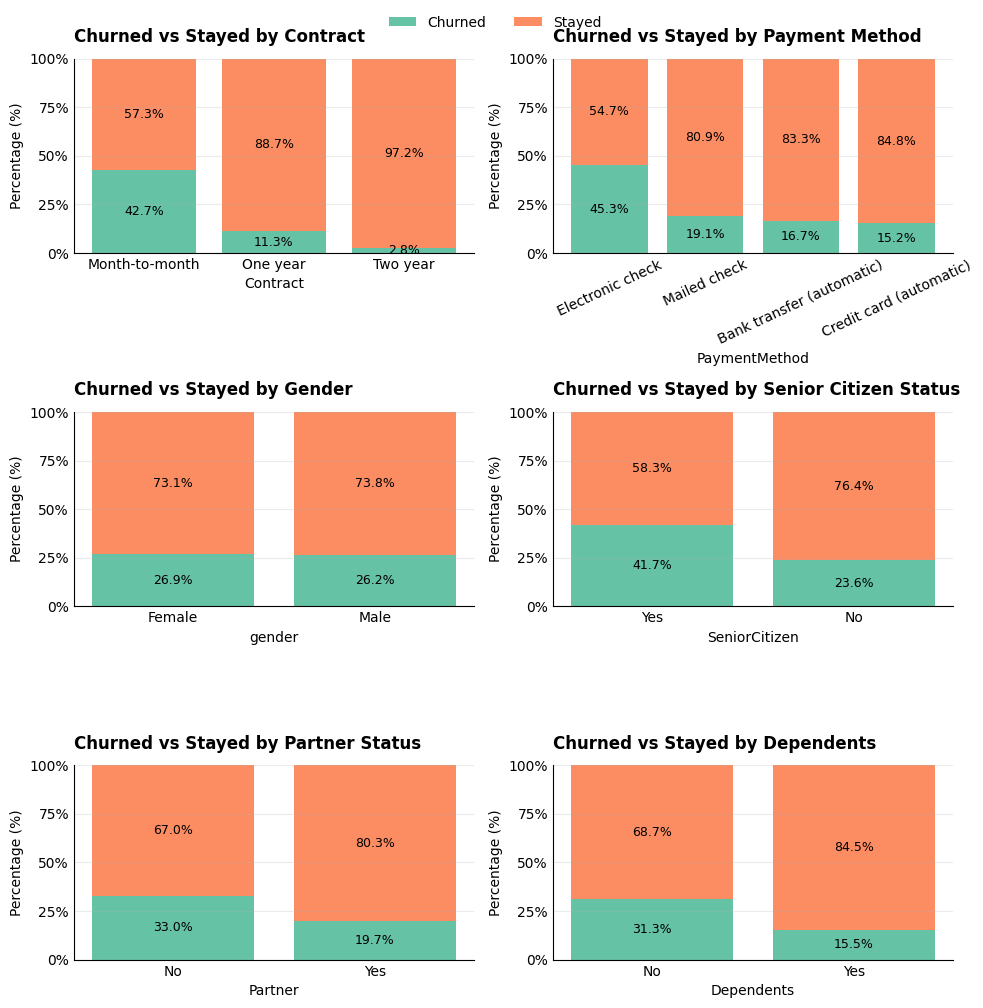

In [49]:
fig, ax = plt.subplot_mosaic(
    [
        ['contract', 'payment'],
        ['gender', 'senior'],
        ['partner', 'dependents']
    ],
    figsize=(10, 10)
)

# -----------------------------------
# Helper function
# -----------------------------------

def stacked_bar(ax, data, category, title):
    
    x = range(len(data))
    
    # Churned
    ax.bar(
        x,
        data['churned_pct'],
        label='Churned',
        color=churned_color
    )
    
    # Stayed
    ax.bar(
        x,
        data['stayed_pct'],
        bottom=data['churned_pct'],
        label='Stayed',
        color=stayed_color
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(data[category])
    
    apply_house_style(
        ax,
        title=title,
        xlabel=category,
        ylabel='Percentage (%)'
    )
    
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    
    # Churned labels
    for i, value in enumerate(data['churned_pct']):
        ax.text(
            i,
            value / 2,
            f'{value:.1f}%',
            ha='center',
            va='center',
            fontsize=9
        )
    
    # Stayed labels
    for i, (churned, stayed) in enumerate(
        zip(data['churned_pct'], data['stayed_pct'])
    ):
        ax.text(
            i,
            churned + stayed / 2,
            f'{stayed:.1f}%',
            ha='center',
            va='center',
            fontsize=9
        )


# -----------------------------------
# Create each visual
# -----------------------------------

stacked_bar(
    ax['contract'],
    contract,
    'Contract',
    'Churned vs Stayed by Contract'
)

stacked_bar(
    ax['payment'],
    payment,
    'PaymentMethod',
    'Churned vs Stayed by Payment Method'
)

stacked_bar(
    ax['gender'],
    gender,
    'gender',
    'Churned vs Stayed by Gender'
)

stacked_bar(
    ax['senior'],
    senior,
    'SeniorCitizen',
    'Churned vs Stayed by Senior Citizen Status'
)

stacked_bar(
    ax['partner'],
    partner,
    'Partner',
    'Churned vs Stayed by Partner Status'
)

stacked_bar(
    ax['dependents'],
    dependents,
    'Dependents',
    'Churned vs Stayed by Dependents'
)


# -----------------------------------
# Rotate long payment labels
# -----------------------------------

ax['payment'].tick_params(
    axis='x',
    rotation=25
)


# -----------------------------------
# Common legend
# -----------------------------------

handles, labels = ax['contract'].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False
)

# Remove individual legends
for axis in ax.values():
    axis.legend_.remove() if axis.legend_ else None


plt.tight_layout()
plt.show()

****

In [50]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'expected_total', 'charge_diff', 'charge_diff_group', 'tenure_group'],
      dtype='object')

**Multi-category columns → One-hot encoding**

In [51]:
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
    'tenure_group'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    dtype=int
)

In [52]:
df_encoded.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'expected_total', 'charge_diff',
       'charge_diff_group', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract

In [53]:
corr_col = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MonthlyCharges',
    'TotalCharges',
    'expected_total',
    'charge_diff',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'InternetService_No',
    'Contract_Month-to-month',
    'Contract_One year',
    'Contract_Two year',
    'PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check',
    'tenure_group_0-12 (1 year)',
    'tenure_group_12-24 (2 years)',
    'tenure_group_24-48 (4 years)',
    'tenure_group_48-60 (5 years)',
    'tenure_group_60-72 (6 years)',
    'Churn'
]

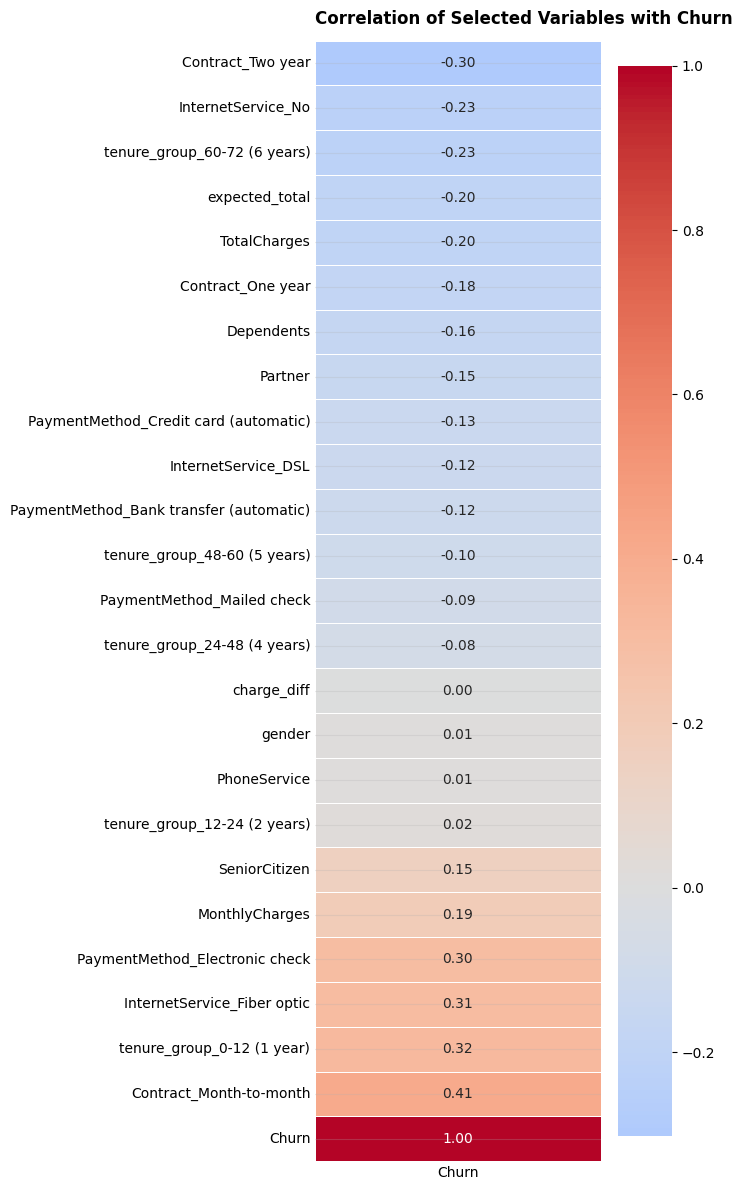

In [54]:
churn_corr = (
    df_encoded[corr_col]
    .corr()[['Churn']]
    .sort_values('Churn')
)

fig, ax = plt.subplots(figsize=(7, 12))

sns.heatmap(
    churn_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    ax=ax
)

apply_house_style(
    ax,
    title='Correlation of Selected Variables with Churn'
)

plt.tight_layout()
plt.show()

In [55]:
df_plot = df.copy()

df_plot['Churn'] = df_plot['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})

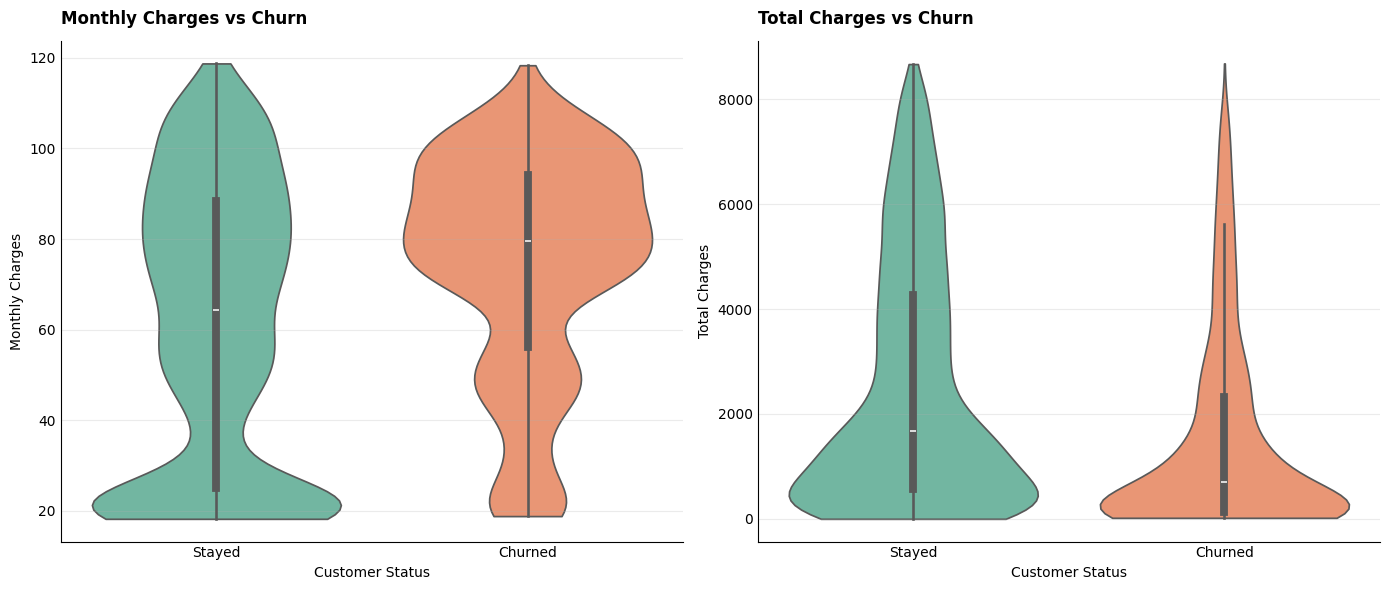

In [56]:
palette = sns.color_palette("Set2", 2)

fig, ax = plt.subplot_mosaic(
    [['monthly', 'total']],
    figsize=(14, 6)
)

# Monthly Charges
sns.violinplot(
    data=df_plot,
    cut=0,
    x='Churn',
    y='MonthlyCharges',
    hue='Churn',
    palette=palette,
    legend=False,
    inner='box',
    ax=ax['monthly']
)

apply_house_style(
    ax=ax['monthly'],
    title='Monthly Charges vs Churn',
    xlabel='Customer Status',
    ylabel='Monthly Charges'
)

# Total Charges
sns.violinplot(
    data=df_plot,
    cut=0,
    x='Churn',
    y='TotalCharges',
    hue='Churn',
    palette=palette,
    legend=False,
    inner='box',
    ax=ax['total']
)

apply_house_style(
    ax=ax['total'],
    title='Total Charges vs Churn',
    xlabel='Customer Status',
    ylabel='Total Charges'
)

plt.tight_layout()
plt.show()

## Hypothesis Testing

**Is there a significant relationship between contract type and customer churn?**

*Chi Square Test*

**H0**

      Contract type and churn are independent.

**H1**

      Contract type and churn are associated.

In [57]:
contract_contingency_table = pd.crosstab(
      df['Contract'],
      df['Churn']
)

contract_contingency_table

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [58]:
chi2, p, dof, expected = stats.chi2_contingency(contract_contingency_table)

expected_df = pd.DataFrame(
      expected,
      index = contract_contingency_table.index,
      columns = contract_contingency_table.columns
)

expected_df

Churn,0,1
Contract,,
Month-to-month,2846.691751,1028.308249
One year,1082.110180,390.889820
Two year,1245.198069,449.801931


In [59]:
print("Minimum expected frequency:", expected.min())
print("Expected frequencies < 5:", (expected < 5).sum())

Minimum expected frequency: 390.889819679114
Expected frequencies < 5: 0


In [60]:
print("\nChi-square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")


Chi-square Test Results:
Chi-square statistic: 1184.5966
Degrees of freedom: 2
P-value: 0.0000


In [61]:
# Effect size: Cramér's V
n = np.sum(contract_contingency_table.values)
min_dim = min(contract_contingency_table.shape) - 1

cramers_v = np.sqrt(chi2/(n * min_dim))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.4101


A Chi-square test of independence found a **statistically significant association** between contract type and customer churn, χ²(2) = 1184.60, p < 0.001. Therefore, the null hypothesis was **rejected**. Cramér's V was 0.4101, indicating a **moderate association between contract type and customer churn**.

**Do Monthly Charges and Total Charges differ significantly between churned and retained customers?**

*Assumptions*

Normality

Shapiro-Wilk Test

H0​:

      The data follow a normal distribution

H1​:

      The data do not follow a normal distribution

In [62]:
# groups
monthly_churned = df.loc[df['Churn'] == 1, 'MonthlyCharges'].dropna()
monthly_stayed = df.loc[df['Churn'] == 0, 'MonthlyCharges'].dropna()

# Check the groups
print("Churned:", len(monthly_churned))
print("Stayed:", len(monthly_stayed))

print("\nChurned data type:", monthly_churned.dtype)
print("Stayed data type:", monthly_stayed.dtype)

Churned: 1869
Stayed: 5174

Churned data type: float64
Stayed data type: float64


In [63]:
# Create the groups
total_churned = df.loc[df['Churn'] == 1, 'TotalCharges'].dropna()
total_stayed = df.loc[df['Churn'] == 0, 'TotalCharges'].dropna()

# Check the groups
print("Churned:", len(total_churned))
print("Stayed:", len(total_stayed))

print("\nChurned data type:", total_churned.dtype)
print("Stayed data type:", total_stayed.dtype)

Churned: 1869
Stayed: 5174

Churned data type: float64
Stayed data type: float64


In [64]:
shapiro_monthly_churn = stats.shapiro(monthly_churned)
shapiro_monthly_stayed = stats.shapiro(monthly_stayed)

print('Shapiro-Wilk Test')
print('\nMonthly Charges')

print('\nChurned')
print(f'Statistic: {shapiro_monthly_churn.statistic:.4f}')
print(f'P-value: {shapiro_monthly_churn.pvalue:.4f}')

print('\nStayed')
print(f'Statistic: {shapiro_monthly_stayed.statistic:.4f}')
print(f'P-value: {shapiro_monthly_stayed.pvalue:.4f}')

Shapiro-Wilk Test

Monthly Charges

Churned
Statistic: 0.9284
P-value: 0.0000

Stayed
Statistic: 0.9129
P-value: 0.0000


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5174.
  res = hypotest_fun_out(*samples, **kwds)


In [65]:
shapiro_total_churned = stats.shapiro(total_churned)
shapiro_total_stayed = stats.shapiro(total_stayed)

print("\nShapiro-Wilk Test")

print("\nTotal Charges")

print("\nChurned")
print(f"Statistic: {shapiro_total_churned.statistic:.4f}")
print(f"P-value: {shapiro_total_churned.pvalue:.4f}")

print("\nStayed")
print(f"Statistic: {shapiro_total_stayed.statistic:.4f}")
print(f"P-value: {shapiro_total_stayed.pvalue:.4f}")


Shapiro-Wilk Test

Total Charges

Churned
Statistic: 0.7787
P-value: 0.0000

Stayed
Statistic: 0.8832
P-value: 0.0000


Since p < 0.001 for every group, you reject the Shapiro–Wilk null hypothesis of normality.

Levene's Test

In [66]:
levene_monthly = stats.levene(
    monthly_churned,
    monthly_stayed
)

print("Levene's Test - Monthly Charges")
print(f"Statistic: {levene_monthly.statistic:.4f}")
print(f"P-value: {levene_monthly.pvalue:.4f}")

Levene's Test - Monthly Charges
Statistic: 361.8445
P-value: 0.0000


In [67]:
levene_total = stats.levene(
    total_churned,
    total_stayed
)

print("Levene's Test - Total Charges")
print(f"Statistic: {levene_total.statistic:.4f}")
print(f"P-value: {levene_total.pvalue:.4f}")

Levene's Test - Total Charges
Statistic: 166.3004
P-value: 0.0000


Levene’s test indicated significant differences in variance between churned and retained customers for both Monthly Charges, F = 361.84, p < 0.001, and Total Charges, F = 166.30, p < 0.001. Therefore, the assumption of homogeneity of variances was violated for both variables.

**Mann–Whitney U**

**H₀:** 

      No significant difference in charges between churned and stayed customers.
**H₁:** 

      Significant difference in charges between churned and stayed customers.


In [68]:
# Mann-Whitney U Test - Monthly Charges
mann_monthly = stats.mannwhitneyu(
    monthly_churned,
    monthly_stayed,
    alternative='two-sided'
)

print("Mann-Whitney U Test - Monthly Charges")
print(f"U Statistic: {mann_monthly.statistic:.4f}")
print(f"P-value: {mann_monthly.pvalue:.4f}")


# Mann-Whitney U Test - Total Charges
mann_total = stats.mannwhitneyu(
    total_churned,
    total_stayed,
    alternative='two-sided'
)

print("\nMann-Whitney U Test - Total Charges")
print(f"U Statistic: {mann_total.statistic:.4f}")
print(f"P-value: {mann_total.pvalue:.4f}")

Mann-Whitney U Test - Monthly Charges
U Statistic: 6003125.5000
P-value: 0.0000

Mann-Whitney U Test - Total Charges
U Statistic: 3381224.0000
P-value: 0.0000


(p< 0.001>) < 0.05 for both Monthly Charges and Total Charges
Meaning There is a statistically significant difference between churned and retained customers for both Monthly and Total Charges

**Is there a significant relationship between InternetService type and PaymentMethod combined and customer churn?**

**H₀:** 

      InternetService and PaymentMethod are not significantly associated with customer churn.

**H₁:**

      InternetService and PaymentMethod are significantly associated with customer churn.

In [69]:
df['Internet_Payment'] = (
    df['InternetService'] + '_' + df['PaymentMethod']
)

Internet_Payment_contingency_table = pd.crosstab(
    df['Internet_Payment'],
    df['Churn']
)
Internet_Payment_contingency_table

Churn,0,1
Internet_Payment,,
DSL_Bank transfer (automatic),513,53
DSL_Credit card (automatic),522,72
DSL_Electronic check,441,207
DSL_Mailed check,486,127
Fiber optic_Bank transfer (automatic),459,187
Fiber optic_Credit card (automatic),446,151
Fiber optic_Electronic check,746,849
Fiber optic_Mailed check,148,110
No_Bank transfer (automatic),314,18


In [70]:
chi2, p, dof, expected = stats.chi2_contingency(Internet_Payment_contingency_table)

expected_df = pd.DataFrame(
    expected,
    index=Internet_Payment_contingency_table.index,
      columns=Internet_Payment_contingency_table.columns
)
expected_df

Churn,0,1
Internet_Payment,,
DSL_Bank transfer (automatic),415.800653,150.199347
DSL_Credit card (automatic),436.370297,157.629703
DSL_Electronic check,476.040324,171.959676
DSL_Mailed check,450.328269,162.671731
Fiber optic_Bank transfer (automatic),474.571063,171.428937
Fiber optic_Credit card (automatic),438.574187,158.425813
Fiber optic_Electronic check,1171.735056,423.264944
Fiber optic_Mailed check,189.534573,68.465427
No_Bank transfer (automatic),243.897203,88.102797


In [71]:
print("\nChi-square Test Results:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")


Chi-square Test Results:
Chi-square statistic: 1083.1290
Degrees of freedom: 11
P-value: 0.0000


In [72]:
# Effect size: Cramér's V
n = np.sum(Internet_Payment_contingency_table.values)
min_dim = min(Internet_Payment_contingency_table.shape) - 1

cramers_v = np.sqrt(chi2/(n * min_dim))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.3922


There is a statistically significant, moderate association between the combined InternetService and PaymentMethod categories and customer churn.

In [73]:
result = (
    df.groupby('Internet_Payment')['Churn']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'Customers',
          'sum': 'Churned',
          'mean': 'Churn Rate'
      })
)

result['Churn Rate'] *= 100

print(result.sort_values('Churn Rate', ascending=False))

                                       Customers  Churned  Churn Rate
Internet_Payment                                                     
Fiber optic_Electronic check                1595      849   53.228840
Fiber optic_Mailed check                     258      110   42.635659
DSL_Electronic check                         648      207   31.944444
Fiber optic_Bank transfer (automatic)        646      187   28.947368
Fiber optic_Credit card (automatic)          597      151   25.293132
DSL_Mailed check                             613      127   20.717781
No_Electronic check                          122       15   12.295082
DSL_Credit card (automatic)                  594       72   12.121212
No_Mailed check                              741       71    9.581646
DSL_Bank transfer (automatic)                566       53    9.363958
No_Bank transfer (automatic)                 332       18    5.421687
No_Credit card (automatic)                   331        9    2.719033


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'expected_total', 'charge_diff', 'charge_diff_group', 'tenure_group',
       'Internet_Payment'],
      dtype='object')

## Model

In [86]:
import statsmodels.formula.api as smf

df_model = df.copy()

logit_model = smf.logit(
    'Churn ~ tenure + MonthlyCharges + TotalCharges + C(Contract) + '
    'C(PaymentMethod) + C(InternetService) + SeniorCitizen + '
    'Partner + Dependents + gender',
    data=df_model
).fit(cov_type='HC3')

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.423304
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7028
Method:                           MLE   Df Model:                           14
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.2684
Time:                        13:07:57   Log-Likelihood:                -2981.3
converged:                       True   LL-Null:                       -4075.1
Covariance Type:                  HC3   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables used in the logistic regression
X_vif = pd.get_dummies(
    df_model[
        [
            'tenure',
            'MonthlyCharges',
            'TotalCharges',
            'Contract',
            'PaymentMethod',
            'InternetService',
            'SeniorCitizen',
            'Partner',
            'Dependents',
            'gender'
        ]
    ],
    drop_first=True,
    dtype=int
)

# Calculate VIF
vif = pd.DataFrame()

vif['Variable'] = X_vif.columns
vif['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Sort from highest to lowest
vif = vif.sort_values('VIF', ascending=False)

print(vif.round(2))

                                 Variable    VIF
1                          MonthlyCharges  17.00
0                                  tenure  15.97
2                            TotalCharges  13.86
12            InternetService_Fiber optic   5.42
8                       Contract_Two year   3.24
4                                 Partner   2.82
10         PaymentMethod_Electronic check   2.73
13                     InternetService_No   2.52
11             PaymentMethod_Mailed check   2.11
7                       Contract_One year   1.99
5                              Dependents   1.97
6                                  gender   1.95
9   PaymentMethod_Credit card (automatic)   1.89
3                           SeniorCitizen   1.36


In [88]:
logit_model_final = smf.logit(
    'Churn ~ tenure + MonthlyCharges + C(Contract) + '
    'C(PaymentMethod) + C(InternetService) + SeniorCitizen + '
    'Partner + Dependents + gender',
    data=df_model
).fit(cov_type='HC3')

print(logit_model_final.summary())

Optimization terminated successfully.
         Current function value: 0.424976
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7029
Method:                           MLE   Df Model:                           13
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.2655
Time:                        13:13:05   Log-Likelihood:                -2993.1
converged:                       True   LL-Null:                       -4075.1
Covariance Type:                  HC3   LLR p-value:                     0.000
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

In [89]:
X_vif = pd.get_dummies(
    df_model[
        [
            'tenure',
            'MonthlyCharges',
            'Contract',
            'PaymentMethod',
            'InternetService',
            'SeniorCitizen',
            'Partner',
            'Dependents',
            'gender'
        ]
    ],
    drop_first=True,
    dtype=int
)

vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values('VIF', ascending=False)

print(vif.round(2))

                                 Variable    VIF
1                          MonthlyCharges  15.99
0                                  tenure   6.92
11            InternetService_Fiber optic   5.25
7                       Contract_Two year   3.24
3                                 Partner   2.82
9          PaymentMethod_Electronic check   2.56
12                     InternetService_No   2.12
10             PaymentMethod_Mailed check   2.07
6                       Contract_One year   1.99
4                              Dependents   1.96
5                                  gender   1.93
8   PaymentMethod_Credit card (automatic)   1.85
2                           SeniorCitizen   1.35


In [90]:
results_final = pd.DataFrame({
    'Coefficient': logit_model_final.params,
    'Odds Ratio': np.exp(logit_model_final.params),
    'P-value': logit_model_final.pvalues,
    'CI Lower': np.exp(logit_model_final.conf_int()[0]),
    'CI Upper': np.exp(logit_model_final.conf_int()[1])
})

print(results_final.round(4))

                                             Coefficient  Odds Ratio  P-value  \
Intercept                                        -0.6580      0.5179   0.0003   
C(Contract)[T.One year]                          -0.7548      0.4701   0.0000   
C(Contract)[T.Two year]                          -1.5346      0.2155   0.0000   
C(PaymentMethod)[T.Credit card (automatic)]      -0.0692      0.9331   0.5389   
C(PaymentMethod)[T.Electronic check]              0.4225      1.5258   0.0000   
C(PaymentMethod)[T.Mailed check]                 -0.0587      0.9430   0.5892   
C(InternetService)[T.Fiber optic]                 0.8938      2.4444   0.0000   
C(InternetService)[T.No]                         -0.7690      0.4635   0.0000   
tenure                                           -0.0320      0.9685   0.0000   
MonthlyCharges                                    0.0042      1.0042   0.1617   
SeniorCitizen                                     0.3077      1.3604   0.0003   
Partner                     

In [91]:
results_final = results_final.sort_values(
    'Odds Ratio',
    ascending=False
)

print(results_final.round(4))

                                             Coefficient  Odds Ratio  P-value  \
C(InternetService)[T.Fiber optic]                 0.8938      2.4444   0.0000   
C(PaymentMethod)[T.Electronic check]              0.4225      1.5258   0.0000   
SeniorCitizen                                     0.3077      1.3604   0.0003   
gender                                            0.0161      1.0163   0.8007   
Partner                                           0.0099      1.0100   0.8964   
MonthlyCharges                                    0.0042      1.0042   0.1617   
tenure                                           -0.0320      0.9685   0.0000   
C(PaymentMethod)[T.Mailed check]                 -0.0587      0.9430   0.5892   
C(PaymentMethod)[T.Credit card (automatic)]      -0.0692      0.9331   0.5389   
Dependents                                       -0.2067      0.8132   0.0185   
Intercept                                        -0.6580      0.5179   0.0003   
C(Contract)[T.One year]     